In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as st
from pkg import detrend_group, plot_map, plot_map_hatch


In [2]:
import os
os.getcwd()
os.chdir('/Users/caropark/FAO_ag_check_code')

In [3]:
def safe_regress(data, formula=None, yvar=None, xvars=None, ci=None):
    if formula:
        yvar = formula.split("~")[0].strip()
        xvars = formula.split("~")[1].strip().split("+")
        xvars = [x.strip() for x in xvars]


    if formula is None and yvar is None or xvars is None:
        raise ValueError("Provide either formula or yvar + xvars")

    n_obs = len(data.dropna(subset=[yvar] + xvars))
    n_preds = len(xvars) + 1  # +1 for intercept

    if n_obs <= n_preds:
        return pd.DataFrame([{"r2": None, "adj_r2": None}])

    try:
        if formula:
            model = smf.ols(formula=formula, data=data).fit()
        else:
            formula = f"{yvar} ~ {' + '.join(xvars)}"
            model = smf.ols(formula=formula, data=data).fit()

        out = {"r2": model.rsquared,
            "adj_r2": model.rsquared_adj,
            "ftest_pval": model.f_pvalue}
        
        out.update({f"coef_{k}": v for k, v in model.params.items()})
        out.update({f"pval_{k}": v for k, v in model.pvalues.items()})
        
        if ci is not None:
            ci = model.conf_int()
            for k in model.params.index:
                out[f"cilow_{k}"] = ci.loc[k, 0]
                out[f"cihigh_{k}"] = ci.loc[k, 1]

        return pd.DataFrame([out])

    except Exception as e:
        return pd.DataFrame([{"r2": None, "adj_r2": None, "error": str(e)}])

def pval_is_sig(data, column, threshold = 0.05):
    data[f'{column}_pass'] = np.where(data[column] <0.05, True, False )
    return data

def make_pretty_tab_multi(df, cols):
    out = {}
    for col in cols:
        vals = {'low': df.loc[df['quantile']==0.25, col].item(),
            'med': df.loc[df['quantile']==0.5,  col].item(),
            'high': df.loc[df['quantile']==0.75, col].item()}
        out[col] = f"{vals['med']} ({vals['low']}, {vals['high']})"
    return pd.Series(out)



In [4]:
yields = pd.read_csv("./data/yields.csv")
yields= yields.loc[:, ~yields.columns.str.contains("_lag|_lead|fao_idx|gridcells", regex=True)]

sm_tmax = pd.read_csv("./data/sm_tmax.csv")
yields_clim = yields.merge(sm_tmax, how="left", on = ["year", "cropname", "country"])

yields_clim = detrend_group(yields_clim, "sm_og", "sm_dt")
yields_clim = detrend_group(yields_clim, "tmax_og", "tmax_dt")

yields_clim = yields_clim[yields_clim.notna()]

counts = yields_clim[["country", "cropname"]].value_counts()
counts_idx = counts[counts>10].index
yields_clim10 = yields_clim.set_index(['country', 'cropname'])
yields_clim10 =  yields_clim10.loc[counts_idx].reset_index()


In [5]:
res_surv = yields_clim10.groupby(['cropname', 'country']).apply(
    lambda group: safe_regress(group, formula= "yield_log_dt ~ sm_dt + tmax_dt")
    ).reset_index(level=[0,1])
res_surv = res_surv.iloc[:, ~res_surv.columns.str.contains("Intercept", regex=True)]
res_surv['model']="Survey"

res_sat = yields_clim10.groupby(['cropname', 'country']).apply(
    lambda group: safe_regress(group, formula= "csif_log_dt ~ sm_dt + tmax_dt")
    ).reset_index(level=[0,1])
res_sat = res_sat.iloc[:, ~res_sat.columns.str.contains("Intercept", regex=True)]
res_sat['model'] = "Satellite"

res_comb= pd.concat([res_sat, res_surv]).reset_index(drop=True)

[pval_is_sig(res_comb, col) for col in ['pval_sm_dt', 'pval_tmax_dt', 'ftest_pval']]
res_comb= res_comb.dropna(how="any")



In [6]:
# cols = ["adj_r2", "r2", "coef_sm_dt", "coef_tmax_dt"]
# nice_tab1_allcrops = res_comb.groupby('model')[['r2', 'adj_r2', 'coef_sm_dt', 'coef_tmax_dt']
#                                                ].quantile([0.25, 0.5, 0.75]).round(2).reset_index(
#                                                ).rename({'level_1': 'quantile'}, axis=1).groupby('model').apply(lambda x: make_pretty_tab_multi(x, cols))
# nice_tab2_allcrops = res_comb.groupby('model')[['pval_sm_dt_pass', 'pval_tmax_dt_pass', 'ftest_pval_pass']].agg(lambda x: str(int(round((sum(x)/ len(x)*100),0)))+"%")


# nice_tab_allcrops = pd.merge(nice_tab1_allcrops, nice_tab2_allcrops, right_on = "model", left_on="model")
# nice_tab_allcrops['cropname'] = "All crops"
# nice_tab_allcrops = nice_tab_allcrops.reset_index().set_index(['cropname', 'model'])



In [7]:
# wanted = res_comb[res_comb['cropname'].isin(["Maize", "Sorghum", "Wheat", "Potatoes", "Cassava"]) ]

# nice_tab1 = wanted.groupby(['cropname', 'model'])[['r2', 'adj_r2', 'coef_sm_dt', 'coef_tmax_dt']
#                                                   ].quantile([0.25, 0.5, 0.75]).round(2).reset_index(
#                                                   ).rename({'level_2': 'quantile'}, axis=1
#                                                   ).groupby(['cropname', 'model']).apply(lambda x: make_pretty_tab_multi(x, cols))

# nice_tab2= wanted.groupby(['cropname', 'model'])[['pval_sm_dt_pass', 'pval_tmax_dt_pass', 'ftest_pval_pass']].agg(lambda x: str(int(round((sum(x)/ len(x)*100),0)))+ "%")
# nice_table =  pd.merge(nice_tab1, nice_tab2, left_on=(['cropname', "model"]), right_on=(['cropname', 'model']))
# nice_table = pd.concat([nice_tab_allcrops, nice_table])


In [8]:
# order = ["All crops", "Maize", "Sorghum", "Wheat", "Cassava", "Potatoes"]
# nice_table = nice_table.iloc[: , [1,0, 6, 2,4]].loc[order,:]
# nice_table.columns=['R2', "Adj R2", "F-test pass", "SM coefficient", "SM p.v. pass"]



In [9]:
# table = nice_table.copy()
# cols_to_clean = ["R2", "Adj R2"]
# table[cols_to_clean] = table[cols_to_clean].replace(r"\s*\([^)]*\)", "", regex=True)

# print(table.to_latex())


In [10]:
# full_table = nice_table.replace(r"(\d+\.\d+)\s\(([^)]+)\)", r"\\makecell{\1 \\\\ (\2)}", regex=True)
# full_table = full_table.replace("%", r"\\%", regex=True)

# print(full_table.to_latex(escape=False))


 ### SM MAPS

In [11]:
country_key = pd.read_csv("./data/country_key.csv")

regs_sm = res_comb[['cropname', 'country', 'coef_sm_dt', 'pval_sm_dt', 'model']
                                                    ].merge(country_key[["iso_a3", "country"]], how="left", on="country")
wb_class = pd.read_csv("./data/wb_classification.csv")[['iso_a3', "class"]]
regs_sm= regs_sm.merge(wb_class, how="left", on="iso_a3")

regs_sm


,cropname,country,coef_sm_dt,pval_sm_dt,model,iso_a3,class
0,Barley,Afghanistan,19.145458,0.000327,Satellite,AFG,Low income
1,Barley,Albania,2.528349,0.148650,Satellite,ALB,Upper middle income
2,Barley,Algeria,11.822276,0.015573,Satellite,DZA,Upper middle income
3,Barley,Argentina,6.383780,0.003417,Satellite,ARG,Upper middle income
4,Barley,Armenia,-1.295867,0.435669,Satellite,ARM,Upper middle income
...,...,...,...,...,...,...,...
3461,Yams,Sudan (former),-0.029232,0.784937,Survey,F206,NaN
3462,Yams,Togo,7.173856,0.004224,Survey,TGO,Low income
3463,Yams,Trinidad and Tobago,14.540445,0.088792,Survey,TTO,High income
3464,Yams,United Republic of Tanzania,-1.030911,0.461554,Survey,TZA,Lower middle income


In [12]:
from scipy.stats import norm

df = regs_sm.copy() #[regs_sm['model']=="Satellite"].copy()

# recover t-stat
df['t'] = norm.ppf(1 - df['pval_sm_dt']/2)

# recover standard error
df['se'] = np.abs(df['coef_sm_dt'] / df['t'])

# inverse variance weight
df['w'] = 1 / df['se']**2

In [13]:
country_coef = (
    df.groupby(['iso_a3', 'model'])
      .apply(lambda g: np.sum(g.coef_sm_dt * g.w) / np.sum(g.w))
      .rename('coef_sm_dt')
)

def combine_p(g):
    z = np.sign(g.coef_sm_dt) * norm.ppf(1 - g.pval_sm_dt/2)
    zc = np.sum(z * np.sqrt(g.w)) / np.sqrt(np.sum(g.w))
    return 2*(1 - norm.cdf(abs(zc)))

country_p = df.groupby(['iso_a3', 'model']).apply(combine_p).rename('pval_sm_dt')

country_sm = pd.concat([country_coef, country_p], axis=1).reset_index()


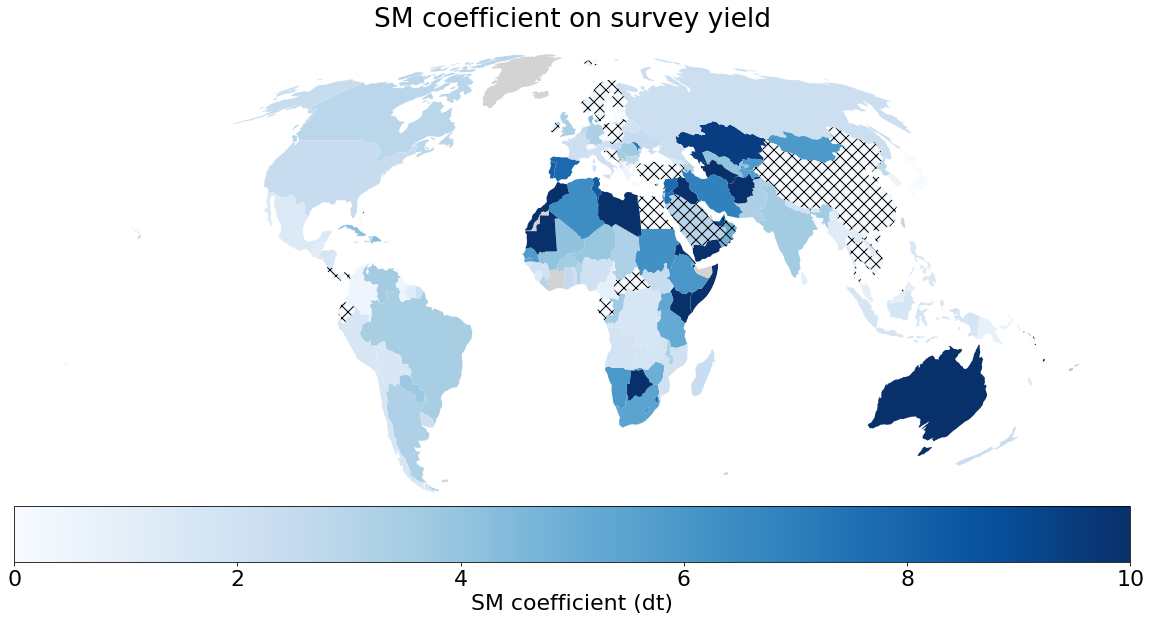

In [25]:
plot_map_hatch(
    country_sm[country_sm['model']=="Satellite"] ,
    column="coef_sm_dt",
    title="SM coefficient on survey yield",
    cbar_label="SM coefficient (dt)",
    cmap="Blues",
    vmin=0, vmax=10,
    filename="satellite_weather_sm",
    hatch_col="pval_sm_dt"
)


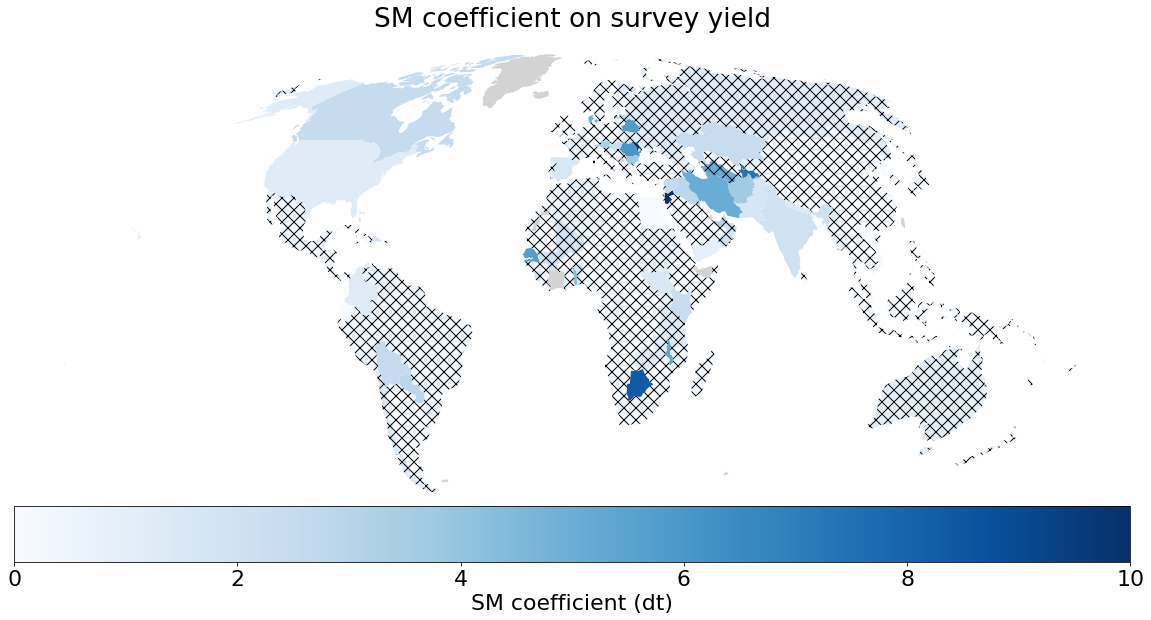

In [26]:
plot_map_hatch(
    country_sm[country_sm['model']=="Survey"] ,
    column="coef_sm_dt",
    title="SM coefficient on survey yield",
    cbar_label="SM coefficient (dt)",
    cmap="Blues",
    vmin=0, vmax=10,
    filename="survey_weather_sm",
    hatch_col="pval_sm_dt"
)


ADJUSTED R2

In [16]:
country_key = pd.read_csv("./data/country_key.csv")

regs = res_comb[['cropname', 'country', 'adj_r2', 'coef_sm_dt', 'model']
                                                    ].merge(country_key[["iso_a3", "country"]], how="left", on="country")
wb_class = pd.read_csv("./data/wb_classification.csv")[['iso_a3', "class"]]
regs= regs.merge(wb_class, how="left", on="iso_a3")



In [17]:
test = regs.groupby(['iso_a3', 'model']).mean('adj_r2').reset_index()

In [18]:
test

,iso_a3,model,adj_r2,coef_sm_dt
0,AFG,Satellite,0.407529,12.676390
1,AFG,Survey,0.103004,10.711332
2,AGO,Satellite,0.210944,1.818230
3,AGO,Survey,0.066251,8.571022
4,ALB,Satellite,0.304712,2.120863
...,...,...,...,...
333,ZAF,Survey,0.134070,-1.640833
334,ZMB,Satellite,0.253649,2.368595
335,ZMB,Survey,0.089555,-0.322506
336,ZWE,Satellite,0.559397,6.139094


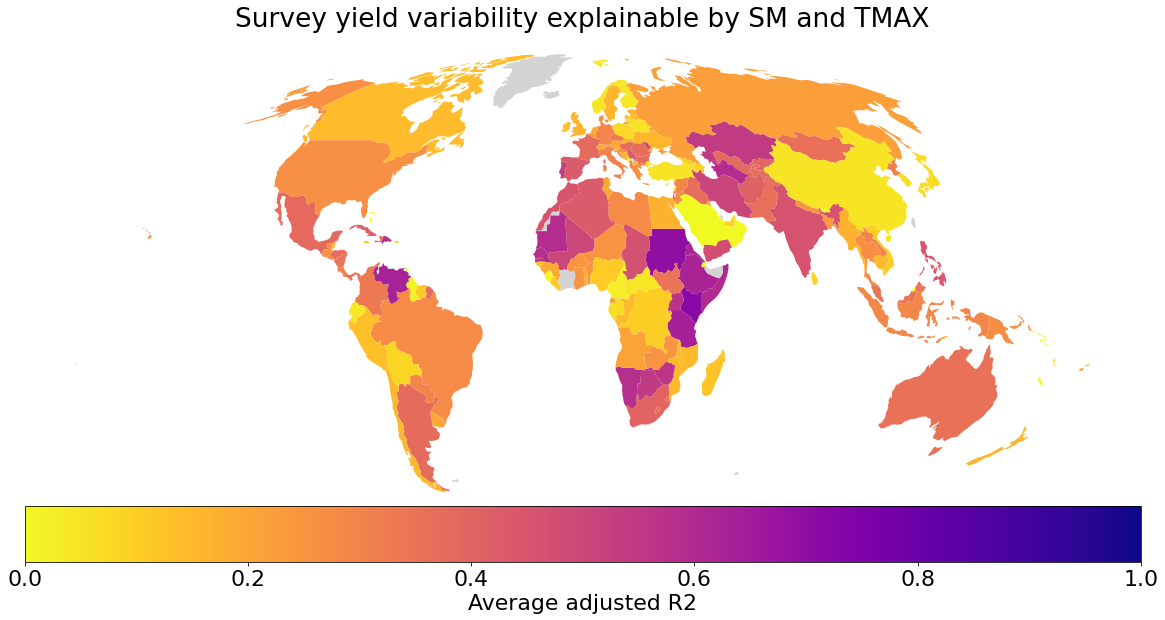

In [ ]:

plot_map(test[test['model']=="Satellite"], column="adj_r2", 
         title="Survey yield variability explainable by SM and TMAX", 
         cbar_label="Average adjusted R2", cmap="plasma_r", vmin=0, vmax=1,
         filename="adj_r2_csif_allcrops.png")


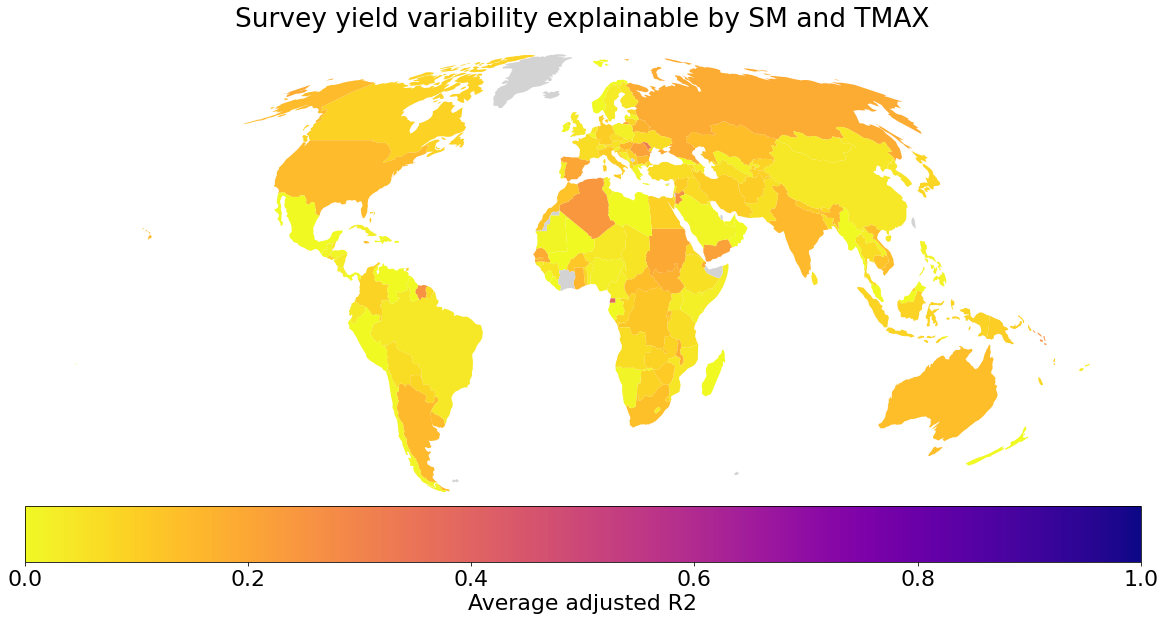

In [ ]:

plot_map(test[test['model']=="Survey"], column="adj_r2", 
         title="Survey yield variability explainable by SM and TMAX", 
         cbar_label="Average adjusted R2", cmap="plasma_r", vmin=0, vmax=1,
         filename="adj_r2_census_allcrops.png")
